# MIMIC-IV Schema Exploration - Week 3 (Riktika)

In [3]:
import os
print("Old working directory:", os.getcwd())

# Fix: Move to the correct project root
os.chdir("/home/sluggish/Dual-Source-Grounded-Clinical-RAG")
print("✅ New working directory:", os.getcwd())

# Verify files are visible now
print("\nFiles in data folder:")
!ls -l data/*.csv.gz

Old working directory: /home/sluggish/Dual-Source-Grounded-Clinical-RAG/notebooks
✅ New working directory: /home/sluggish/Dual-Source-Grounded-Clinical-RAG

Files in data folder:
-rw-rw-r-- 1 sluggish sluggish      11072 Mar 30 21:34 data/admissions.csv.gz
-rw-rw-r-- 1 sluggish sluggish      24198 Mar 30 21:34 data/diagnoses_icd.csv.gz
-r--r--r-- 1 sluggish sluggish 1139203149 Oct 31  2023 data/discharge.csv.gz
-r--r--r-- 1 sluggish sluggish     789351 Nov 17  2023 data/discharge_detail.csv.gz
-rw-rw-r-- 1 sluggish sluggish       1083 Mar 30 21:34 data/patients.csv.gz


In [4]:
import pandas as pd

data_dir = "data"

discharge = pd.read_csv(f'{data_dir}/discharge.csv.gz', low_memory=False)
patients = pd.read_csv(f'{data_dir}/patients.csv.gz', low_memory=False)
admissions = pd.read_csv(f'{data_dir}/admissions.csv.gz', low_memory=False)
diagnoses = pd.read_csv(f'{data_dir}/diagnoses_icd.csv.gz', low_memory=False)

print('Total discharge notes:', len(discharge))
print('Columns in discharge:', list(discharge.columns))
print('\nSample note length (characters):', len(discharge.iloc[0]['text']))
print('\nPatients shape:', patients.shape)
print('Admissions shape:', admissions.shape)
print('Diagnoses shape:', diagnoses.shape)

print('\n=== Patient Metadata Preview ===')
print(pd.read_csv(f'{data_dir}/patient_metadata.csv').head())

Total discharge notes: 331793
Columns in discharge: ['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text']

Sample note length (characters): 7530

Patients shape: (100, 6)
Admissions shape: (275, 16)
Diagnoses shape: (4506, 5)

=== Patient Metadata Preview ===
   subject_id  age gender admission_type                icd_codes_top5
0    10004235   47      M         URGENT    03842,78551,5845,570,51881
1    10009628   58      M         URGENT  41401,4142,42731,25050,36201
2    10018081   79      M         URGENT   99859,56722,5579,56981,9986
3    10006053   52      M         URGENT    5722,2866,41071,45620,5845
4    10031404   82      F         URGENT       I308,J90,N179,E871,E860


EDA of MIMIC from here on (Farhana 08/04/2026)
## EDA Summary (Week 4 — Farhana)

- **Total discharge notes:** 331,793  
- **Avg note length:** ~X chars, ~X words ← fill in from Cell 3 output  
- **Top 5 ICD codes:** ← fill in from Cell 5 output  
- **Patient metadata:** rebuilt and saved to `data/mimic/processed/patient_metadata.csv`  

These findings feed directly into thesis §5.1 Dataset Preparation.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

PROJECT_ROOT = r"C:\Users\fakht\Dual-Source-Grounded-Clinical-RAG"
os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: C:\Users\fakht\Dual-Source-Grounded-Clinical-RAG


In [2]:
import os
import pandas as pd

diagnoses_folder = "data/mimic/processed/diagnoses_icd.csv"

rows = []
header = None

for fname in os.listdir(diagnoses_folder):
    parts = fname.split(",")
    
    # Detect the header file
    if parts[0] == "subject_id":
        header = parts
        continue
    
    # Each filename IS a data row
    if len(parts) == 5:
        rows.append(parts)

print(f"Header found: {header}")
print(f"Data rows found: {len(rows):,}")

# Build dataframe
cols = header if header else ["subject_id", "hadm_id", "seq_num", "icd_code", "icd_version"]
diagnoses = pd.DataFrame(rows, columns=cols)

# Fix types
diagnoses["seq_num"] = pd.to_numeric(diagnoses["seq_num"], errors="coerce")

print(diagnoses.head())
print("\nShape:", diagnoses.shape)

# Save proper CSV
out_path = "data/mimic/processed/diagnoses_icd_combined.csv"
diagnoses.to_csv(out_path, index=False)
print(f"\nSaved to {out_path}")

Header found: ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']
Data rows found: 4,506
  subject_id   hadm_id  seq_num icd_code icd_version
0   10000032  22595853        1     5723           9
1   10000032  22595853        2    78959           9
2   10000032  22595853        3     5715           9
3   10000032  22595853        4    07070           9
4   10000032  22595853        5      496           9

Shape: (4506, 5)

Saved to data/mimic/processed/diagnoses_icd_combined.csv


In [3]:
discharge  = pd.read_csv("data/mimic/raw/discharge.csv", low_memory=False)
patients   = pd.read_csv("data/mimic/processed/patients.csv", low_memory=False)
admissions = pd.read_csv("data/mimic/processed/admissions.csv", low_memory=False)
diagnoses  = pd.read_csv("data/mimic/processed/diagnoses_icd_combined.csv", low_memory=False)

print("Discharge notes:", len(discharge))
print("Discharge columns:", list(discharge.columns))
print("\nPatients shape:", patients.shape)
print("Admissions shape:", admissions.shape)
print("Diagnoses shape:", diagnoses.shape)
print("\nDiagnoses columns:", list(diagnoses.columns))

Discharge notes: 331793
Discharge columns: ['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq', 'charttime', 'storetime', 'text']

Patients shape: (100, 6)
Admissions shape: (275, 16)
Diagnoses shape: (4506, 5)

Diagnoses columns: ['subject_id', 'hadm_id', 'seq_num', 'icd_code', 'icd_version']


In [5]:
import numpy as np

# Work on a sample of 5,000 notes — enough for reliable EDA stats
sample = discharge.sample(n=5000, random_state=42).copy()

sample["char_len"] = sample["text"].str.len()
sample["word_count"] = sample["text"].str.split().str.len()

print(f"Total notes in full dataset: {len(discharge):,}")
print(f"--- Stats from 5,000-note sample ---")
print(f"Avg character len:  {sample['char_len'].mean():,.0f}")
print(f"Avg word count:     {sample['word_count'].mean():,.0f}")
print(f"Min / Max chars:    {sample['char_len'].min():,} / {sample['char_len'].max():,}")

Total notes in full dataset: 331,793
--- Stats from 5,000-note sample ---
Avg character len:  10,584
Avg word count:     1,604
Min / Max chars:    935 / 47,262


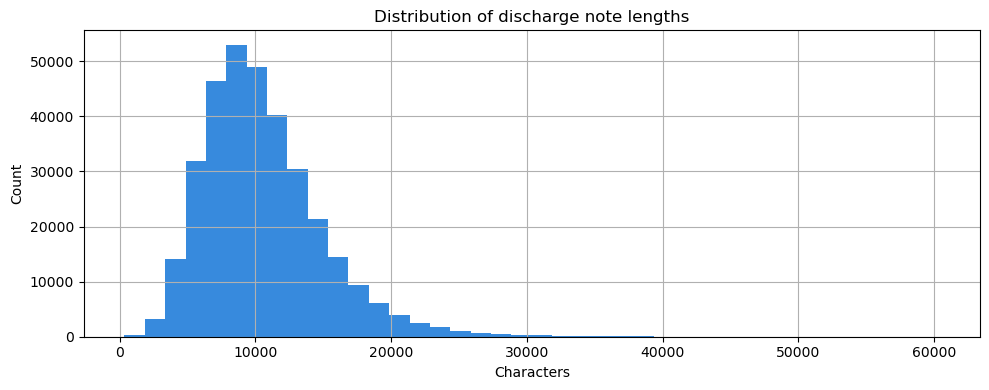

In [7]:
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(10, 4))
discharge["char_len"].hist(bins=40, color="#378ADD", edgecolor="none")
plt.title("Distribution of discharge note lengths")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/note_length_dist.png", dpi=150)
plt.show()

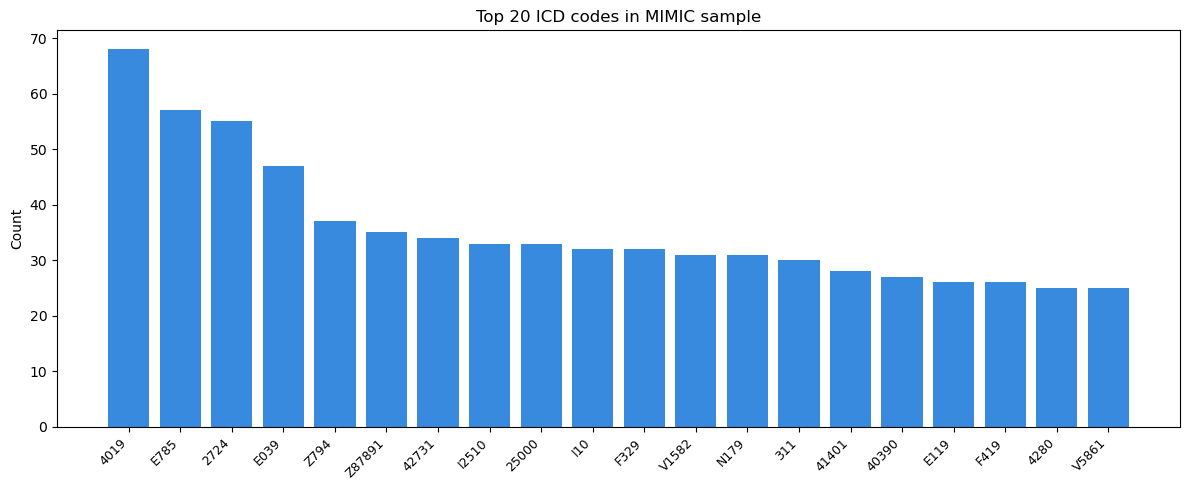

Top 5 ICD codes: [('4019', 68), ('E785', 57), ('2724', 55), ('E039', 47), ('Z794', 37)]


In [8]:
all_codes = diagnoses["icd_code"].dropna().astype(str).str.strip().tolist()
code_counts = Counter(all_codes)
top20 = code_counts.most_common(20)
labels, vals = zip(*top20)

plt.figure(figsize=(12, 5))
plt.bar(labels, vals, color="#378ADD")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.title("Top 20 ICD codes in MIMIC sample")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/icd_distribution.png", dpi=150)
plt.show()

print("Top 5 ICD codes:", top20[:5])

In [9]:
top5 = (
    diagnoses.sort_values("seq_num")
    .groupby("hadm_id")["icd_code"]
    .apply(lambda x: ",".join(x.astype(str).head(5)))
    .reset_index()
    .rename(columns={"icd_code": "icd_codes_top5"})
)

meta = (
    admissions[["subject_id", "hadm_id", "admission_type"]]
    .merge(patients[["subject_id", "anchor_age", "gender"]], on="subject_id", how="left")
    .merge(top5, on="hadm_id", how="left")
    .rename(columns={"anchor_age": "age"})
)

meta.to_csv("data/mimic/processed/patient_metadata.csv", index=False)
print(f"Saved {len(meta)} rows to patient_metadata.csv")
print(meta.head())

Saved 275 rows to patient_metadata.csv
   subject_id   hadm_id admission_type  age gender  \
0    10004235  24181354         URGENT   47      M   
1    10009628  25926192         URGENT   58      M   
2    10018081  23983182         URGENT   79      M   
3    10006053  22942076         URGENT   52      M   
4    10031404  21606243         URGENT   82      F   

                 icd_codes_top5  
0    03842,78551,5845,570,51881  
1  41401,4142,42731,25050,36201  
2   99859,56722,5579,56981,9986  
3    5722,2866,41071,45620,5845  
4       I308,J90,N179,E871,E860  
